In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
n_train = 100
n_test = 100
num_inputs = 200
batch_size = 5

true_w = torch.ones((num_inputs, 1)) * 0.01
true_b = 0.05

train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)

test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [3]:
def init_params():
    w=torch.normal(0,1,size=(num_inputs,1),requires_grad=True)
    b=torch.zeros(1,requires_grad=True)
    return [w,b]

In [12]:
def l2_penalty(w):
    return torch.sum(w.pow(2))/2

In [13]:
def train(lambd):
    w, b = init_params()
    net = lambda X: d2l.linreg(X, w, b)
    loss = d2l.squared_loss
    num_epochs, lr = 100, 0.003
    
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                             xlim=[5, num_epochs], legend=['train', 'test'])
    
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 前向传播 + 计算损失（包括L2正则化）
            l = loss(net(X), y).sum() + lambd * l2_penalty(w)
            l.backward()  # 反向传播
            d2l.sgd([w, b], lr, batch_size)  # 更新参数
        
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, 
                        (d2l.evaluate_loss(net, train_iter, loss),
                         d2l.evaluate_loss(net, test_iter, loss)))
    
    print('w的L2范数是:', torch.norm(w).item())
    return w, b

w的L2范数是: 9.812149047851562


(tensor([[-3.3197e-01],
         [ 7.5046e-01],
         [-1.3582e+00],
         [-2.3836e-01],
         [ 1.2957e-01],
         [-5.2085e-01],
         [-4.6846e-01],
         [-4.1705e-02],
         [ 8.6042e-01],
         [-8.3562e-02],
         [-1.2396e-01],
         [ 2.4259e-01],
         [-4.4010e-02],
         [ 2.8720e-01],
         [-1.1347e+00],
         [-3.1980e-01],
         [ 1.9254e-01],
         [-9.9414e-01],
         [ 3.9329e-01],
         [-1.1422e+00],
         [-1.1264e-01],
         [ 9.5620e-01],
         [ 1.0298e+00],
         [ 5.5423e-01],
         [ 2.9001e-01],
         [-1.3454e+00],
         [ 3.4896e-01],
         [-7.5995e-01],
         [-4.2566e-01],
         [-3.2331e-01],
         [ 7.7296e-01],
         [-1.2091e+00],
         [-1.4281e-01],
         [-8.0372e-01],
         [-4.7980e-01],
         [-7.4939e-01],
         [ 2.9650e-01],
         [ 1.0964e+00],
         [-3.9777e-01],
         [ 1.0051e+00],
         [ 1.1753e+00],
         [-5.187

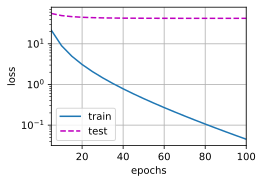

In [14]:
train(lambd=0)

w的L2范数是: 0.2835405766963959


(tensor([[-2.4728e-03],
         [-2.7892e-02],
         [-5.1809e-03],
         [ 8.1417e-03],
         [-2.5680e-02],
         [ 7.1677e-04],
         [ 1.2347e-02],
         [ 1.5477e-02],
         [ 2.0614e-03],
         [-3.2375e-02],
         [-2.9462e-02],
         [ 1.4080e-02],
         [-1.1468e-02],
         [-1.2320e-02],
         [-6.2145e-03],
         [ 1.3626e-02],
         [ 4.0924e-02],
         [-4.0288e-02],
         [ 5.4169e-03],
         [ 7.4387e-04],
         [ 8.9803e-03],
         [ 4.2206e-03],
         [ 1.1432e-02],
         [ 7.1705e-03],
         [-1.1385e-02],
         [-9.5876e-03],
         [-6.7211e-03],
         [ 2.7920e-02],
         [ 9.1352e-03],
         [ 8.8402e-03],
         [-9.4631e-03],
         [ 1.1084e-02],
         [ 9.0690e-03],
         [-3.7085e-03],
         [-7.0417e-03],
         [ 2.7807e-02],
         [ 1.8404e-02],
         [-4.8207e-03],
         [ 3.3269e-02],
         [-6.1257e-03],
         [-2.8146e-02],
         [-2.059

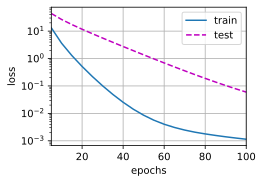

In [15]:
train(lambd=3)